In [11]:
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir('/zhome/71/c/146676/main/')
import SimpleITK as sitk
import importlib
from helpers import module_auxiliary as ma
from matplotlib_scalebar.scalebar import ScaleBar
from cil.optimisation.operators import GradientOperator # For extract edge function
import matplotlib
#matplotlib.use('Agg')
from segmentation import s3_watershed_eds
importlib.reload(s3_watershed_eds)
import matplotlib.colors as mcolors
import copy
from segmentation import s2_watershed_filter
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import mode
from scipy.spatial.distance import cosine, euclidean

In [43]:
full_seg_, segmentation_, elem_segm_, elems_ = s3_watershed_eds.get_segmentation_from_watersheds(
    thresholds = np.array([15, 15, 15, 10 , 20, 20, 30, 12, 5 , 30, 10, 13 , 92, 15, 5]),
    output=True)

elems = {}
for key in elems_:
    if key != "labels":
        
        moving = sitk.GetImageFromArray(elems_[key].astype(np.float32))
        elems[key] = s3_watershed_eds.transform_eds(elems_[key].astype(np.float32),h=1)


full_seg_, segmentation_, elem_segm_, elems_raw_ = s3_watershed_eds.get_segmentation_from_watersheds(
    thresholds = np.array([15, 15, 15, 10 , 20, 20, 30, 12, 5 , 30, 10, 13 , 92, 15, 5]),
    output=True,raw=True)

elems_raw = {}
for key in elems_:
    if key != "labels":
        
        moving = sitk.GetImageFromArray(elems_raw_[key].astype(np.float32))
        elems_raw[key] = s3_watershed_eds.transform_eds(elems_raw_[key].astype(np.float32),h=1)



In [44]:
elems_n = copy.deepcopy(elems)
elements = ['Al', 'Ca', 'Cl', 'Cr', 'Fe',  'K', 'Mg', 'Na', 'Ni',  'O',  'P',  'S', 'Si', 'Ti', 'Zr']
sum_elems = np.zeros(np.shape(elems['Al']))
for element in elements:
    sum_elems = sum_elems + elems[element]

mask = elems['O']>10
for element in elements:
    elems_n[element] = elems_n[element].astype(np.float32)
    elems_n[element][mask] = elems[element][mask]/sum_elems[mask]
    elems_n[element][np.logical_not(mask)] = 0


elems_raw_n = copy.deepcopy(elems_raw)
sum_elems_raw = np.zeros(np.shape(elems_raw['Al']))
for element in elements:
    sum_elems_raw = sum_elems_raw + elems_raw[element]

mask = elems['O']>10
for element in elements:
    elems_raw_n[element] = elems_raw_n[element].astype(np.float32)
    elems_raw_n[element][mask] = elems_raw[element][mask]/sum_elems_raw[mask]
    elems_raw_n[element][np.logical_not(mask)] = 0

/tmp/pbs.513682.hnode41/ipykernel_1182416/2917447538.py:22: RuntimeWarning: invalid value encountered in divide
  elems_raw_n[element][mask] = elems_raw[element][mask]/sum_elems_raw[mask]


In [14]:
NA_surf_volume_ = np.load('/dtu-compute/msaca/cache/NA_surf1.npy')
XA_surf_volume_ = np.load('/dtu-compute/msaca/cache/XA_surf1.npy')
nz, ny, nx = np.shape(XA_surf_volume_)
subvol = [0,nz,30, 40, 0, nx]

NA_surf_volume = NA_surf_volume_[subvol[0]:subvol[1],subvol[2]:subvol[3],subvol[4]:subvol[5]]
XA_surf_volume = XA_surf_volume_[subvol[0]:subvol[1],subvol[2]:subvol[3],subvol[4]:subvol[5]]
XA, NA = s2_watershed_filter.place_medians_in_watersheds(XA_surf_volume, NA_surf_volume,
    eta_edge = 0.005,level = 0.15, conductivity = 0.5, smoothing_iter = 15, watershed_line = False)

Watershedding with level  0.15  and smoothing iter  15
Diffusion time:  59.22920346260071
Gradient time:  11.822258234024048
Watershed time:  53.86048889160156
Assignment time:  1.4057259559631348
Number of watersheds 152082


In [45]:
h = 1
##           ['Al', 'Ca', 'Cl', 'Cr', 'Fe',  'K', 'Mg', 'Na', 'Ni',  'O',  'P',  'S', 'Si', 'Ti', 'Zr']
p_80keV = np.array([0.202, 0.366, 0.269, 0.491, 0.595,  0.325, 0.195, 0.180, 0.731,  0.168,  0.232,  0.259, 0.223, 0.405, 1.72])
p_60keV = np.array([0.278, 0.658, 0.439, 0.964, 1.205,  0.568, 0.257, 2.268, 1.512,  0.190,  0.349,  0.405, 0.321, 0.766, 3.74])
p_73keV = 7/20*p_60keV + 13/20*p_80keV
print(p_73keV)
density_element = [2700, 1550, 2030, 7140, 7874, 856, 1738, 968, 8908,  1495, 1823, 1960, 2330, 4507, 6511]

## 'Feld-An-Al', 'Feld-Al-Or'', 'Pyrox':,
#            'Apatite', 'Chromite', 'Ilminite', 'Pyrite',
#            'Zircon', 'Iron_oxide'}
density_mineral = [2680, 2680, 3300, 3200, 4700, 4500, 5000, 4700, 5200]
keys = list(elems_n.keys())

# Compute the weighted sum
result = sum(1e-5*coeff * elems_n[key] for coeff, key in zip(density_element, keys))

plt.figure(figsize=(10,10))
plt.imshow(result)
a = np.mean(result[0:10])
b = np.mean(result[int(h*500):int(h*600),int(h*500):int(h*600)])
plt.clim([a-(b-a)*0.3, 2*b])
plt.colorbar()
plt.savefig('/dtu-compute/msaca/cache/plot_simXA_att1.png', dpi=300)
plt.close('all')

[0.2286  0.4682  0.3285  0.65655 0.8085  0.41005 0.2167  0.9108  1.00435
 0.1757  0.27295 0.3101  0.2573  0.53135 2.427  ]


In [46]:
##           ['Al', 'Ca', 'Cl', 'Cr', 'Fe',  'K', 'Mg', 'Na', 'Ni',  'O',  'P',  'S', 'Si', 'Ti', 'Zr']
p_80keV = np.array([0.202, 0.366, 0.269, 0.491, 0.595,  0.325, 0.195, 0.180, 0.731,  0.168,  0.232,  0.259, 0.223, 0.405, 1.72])
p_60keV = np.array([0.278, 0.658, 0.439, 0.964, 1.205,  0.568, 0.257, 2.268, 1.512,  0.190,  0.349,  0.405, 0.321, 0.766, 3.74])
p_73keV = 7/20*p_60keV + 13/20*p_80keV
density_element = np.array([2700, 1550, 2030, 7140, 7874, 856, 1738, 968, 8908,  1495, 1823, 1960, 2330, 4507, 6511])
atomic_mass = np.array([26.982, 40.078, 35.450, 51.996, 55.845, 39.098, 24.305, 22.990, 58.693, 16.000, 30.974, 32.065, 28.085, 47.867, 91.224])

## 'Feld-An-Al', 'Feld-Al-Or'', 'Pyrox':,
#            'Apatite', 'Chromite', 'Ilminite', 'Pyrite',
#            'Zircon', 'Iron_oxide'}
density_mineral = np.array([2680, 2680, 3300, 3200, 4700, 4500, 5000, 4700, 5200])
keys = list(elems_n.keys())

# Compute the weighted sum
result = sum(1e-5*coeff * elems_raw_n[key] for coeff, key in zip(density_element, keys))

plt.figure(figsize=(10,10))
plt.imshow(result)
a = np.mean(result[0:10])
b = np.mean(result[int(h*500):int(h*600),int(h*500):int(h*600)])
plt.clim([a-(b-a)*0.3, 2*b])
plt.colorbar()
plt.savefig('/dtu-compute/msaca/cache/plot_simrawXA_att1.png', dpi=300)
plt.close('all')

In [47]:
plt.figure(figsize=(10,10))
plt.imshow(XA[:,7])
plt.colorbar()
a = np.mean(XA[0:10,7])
b = np.mean(XA[500:600,7,500:600])
plt.clim([a-(b-a)*0.3, 2*b])
plt.savefig('/dtu-compute/msaca/cache/plot_XA_att1.png', dpi=300)
plt.close('all')

In [48]:
# Neutron database: https://nds.iaea.org/ngatlas2/
# https://ncnr.nist.gov/resources/n-lengths/
                   ##           ['Al', 'Ca', 'Cl', 'Cr', 'Fe',  'K', 'Mg', 'Na', 'Ni',  'O',  'P',  'S', 'Si', 'Ti', 'Zr']
cross_section_micro_elements = [0.231, 0.43, 33.5, 3.05, 2.56,  2.1, 0.063, 0.53, 4.49, 0.00019,  0.172,  0.53, 0.171, 6.09, 0.185] # At 2200m/s energy (around 25meV)
neutron_absorption = cross_section_micro_elements * density_element/atomic_mass

result = sum(coeff * elems_raw_n[key] for coeff, key in zip(neutron_absorption, keys))

plt.figure(figsize=(10,10))
plt.imshow(result)
a = np.mean(result[0:10])
b = np.mean(result[int(h*500):int(h*600),int(h*500):int(h*600)])
plt.clim([a-(b-a)*0.3, 2*b])
plt.colorbar()
plt.savefig('/dtu-compute/msaca/cache/plot_6_simrawNA_att.png', dpi=300)
plt.close('all')

In [49]:
# Neutron database: https://nds.iaea.org/ngatlas2/
# https://ncnr.nist.gov/resources/n-lengths/

cross_section_micro_elements = [0.231, 0.43, 33.5/50, 3.05, 2.56,  2.1, 0.063, 0.53, 4.49, 0.00019,  0.172,  0.53, 0.171, 6.09/10, 0.185] # At 2200m/s energy (around 25meV)
neutron_absorption = cross_section_micro_elements * density_element/atomic_mass

result = sum(coeff * elems_n[key] for coeff, key in zip(neutron_absorption, keys))

plt.figure(figsize=(10,10))
plt.imshow(result)
a = np.mean(result[0:10])
b = np.mean(result[int(h*500):int(h*600),int(h*500):int(h*600)])
plt.clim([a-(b-a)*0.3, 2*b])
plt.colorbar()
plt.savefig('/dtu-compute/msaca/cache/plot_sim3NA_att.png', dpi=300)
plt.close('all')

In [156]:
plt.figure(figsize=(10,10))
plt.imshow(NA[:,7])
a = np.mean(XA[0:10,7])
b = np.mean(XA[500:600,7,500:600])
plt.clim([a-(b-a)*0.3, 2*b])
plt.colorbar()
plt.savefig('/dtu-compute/msaca/cache/plot_simrawXA_att8.png', dpi=300)
plt.close('all')

#### Let is imply match the weights of the EDS data to the attenuation data

In [154]:
from scipy.optimize import nnls
N = 10
X = NA[:,7,:][mask]
X = X.flatten()[::N]
Y = np.column_stack([arr[mask].flatten()[::N] for arr in elems_n.values()])

w, _ = nnls(Y, X)
print(w/np.sum(w))

[0.01384002 0.         0.08858428 0.06916816 0.26223564 0.06540871
 0.10652366 0.         0.         0.         0.1436461  0.
 0.07720211 0.02697283 0.1464185 ]


In [ ]:
result = sum(coeff * elems_n[key] for coeff, key in zip(w, keys))
result = (result)*mask
plt.figure(figsize=(10,10))
plt.imshow(result)
a = np.mean(result[0:10])
b = np.mean(result[int(h*500):int(h*600),int(h*500):int(h*600)])
plt.clim([a-(b-a)*0.3, 2*b])
plt.colorbar()
plt.savefig('/dtu-compute/msaca/cache/plot_simrawXA_att9.png', dpi=300)
plt.close('all')

In [ ]:

A = np.transpose(Y)@Y
A_inv = np.linalg.inv(A)
YtX = np.transpose(Y)@X
w = A_inv @ YtX
#['Al', 'Ca', 'Cl', 'Cr', 'Fe',  'K', 'Mg', 'Na', 'Ni',  'O',  'P',  'S', 'Si', 'Ti', 'Zr']
print(w/np.sum(w))

[ 0.09699571 -0.18430115  0.33492589  0.2334424   0.65849488  0.06066552
  0.23985843  0.1928401  -1.65924691 -0.26405539  0.36289141  0.10141706
  0.26819032  0.07058924  0.48729248]


In [21]:
# pyroxene mass attenuation coefficient: 7.243933E+04 cm2/g
# Pyroxene density: 3.7 g/cm3

mass_att_density =  7.243933e+4 * 3.7   # cm 1.770510E+00

print(mass_att_density)

268025.521


In [22]:
import numpy as np
#                         ['Al', 'Ca', 'Cl', 'Cr', 'Fe',  'K', 'Mg', 'Na', 'Ni',  'O',  'P',  'S', 'Si', 'Ti', 'Zr']
density_element = np.array([2700, 1550, 2030, 7140, 7874, 856, 1738, 968, 8908,  1495, 1823, 1960, 2330, 4507, 6511])
# Formula NaFe3Si2O6
weights = [0, 0, 0, 0, 3, 0, 0, 1, 0,  6,  0, 0, 2, 0, 0]
 # Fe2Si2O6
weights = [0, 0, 0, 0, 2, 0, 0, 0, 0,  6,  0, 0, 2, 0, 0]
# CaMgSi2O6
weights = [0, 1, 0, 0, 0, 0, 1, 0, 0,  6,  0, 0, 2, 0, 0]
# Ca10(PO4)6Cl2
weights = [0, 10, 2, 0, 0, 0, 0, 0, 0,  24,  6, 0, 0, 0, 0]
dens = np.sum(weights * density_element / np.sum(weights))
print(dens)

1580.4285714285716


In [ ]:
# Can we estimate the linear attenuation coefficient from EDS data in a meaningful way? Naive way: weighted sum over
# w times density of elements. But the actual density denpends on the phases: Now give a qualified guess of the phases: The 
# segmentation assigns ONE phase to ONE pixel. Imagine if we could assign a fractional phase to each pixel determined directly by EDS data.
# Now using this fractional info about the phases, we can do a weighted sum over sum ( w_i   *   mu_{mass,i}   *   rho_{mass,i}), here
# the sum is taken over the phases.


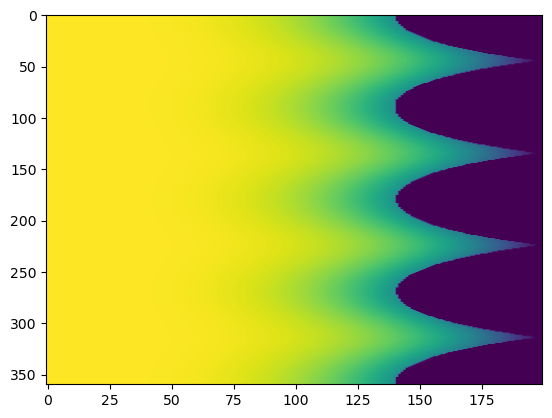

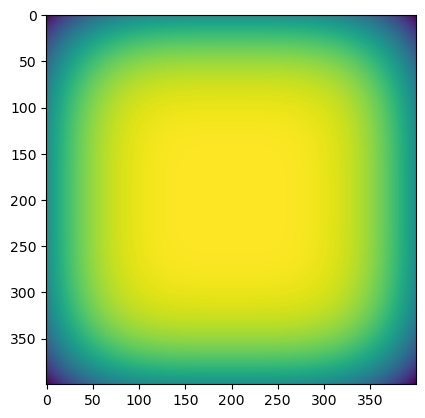

In [81]:
import numpy as np
import scipy.interpolate

def cartesian_to_polar_resample(matrix, num_r=None, num_theta=360):
    rows, cols = matrix.shape
    cx, cy = cols // 2, rows // 2  # Assume the center of the matrix is the origin
    
    # Compute maximum radius
    max_r = np.hypot(cx, cy)
    
    # Define the polar grid
    if num_r is None:
        num_r = int(max_r)  # Default to max possible radius for full coverage
    
    r = np.linspace(0, max_r, num_r)  # Radius values
    theta = np.linspace(0, 2 * np.pi, num_theta)  # Theta values
    R, Theta = np.meshgrid(r, theta)  # Create a polar grid
    
    # Convert polar grid back to Cartesian coordinates
    Xp = cx + R * np.cos(Theta)
    Yp = cy + R * np.sin(Theta)
    
    # Create the Cartesian grid of the original matrix
    x = np.arange(cols)
    y = np.arange(rows)
    X, Y = np.meshgrid(x, y)
    
    # Flatten arrays for interpolation
    points = np.column_stack((X.ravel(), Y.ravel()))
    values = matrix.ravel()
    
    # Interpolate using griddata (bilinear interpolation)
    polar_matrix = scipy.interpolate.griddata(points, values, (Xp, Yp), method='linear', fill_value=0)
    
    return polar_matrix, R, Theta

# Example usage
x = np.linspace(0,1,400)
XX, YY = np.meshgrid(x,x)

matrix = (2-(XX*2-1)**4 - (YY*2-1)**4).astype(np.float32)  # Example 100x100 matrix
polar_matrix, R, Theta = cartesian_to_polar_resample(matrix,200)
plt.imshow(polar_matrix, aspect='auto')
plt.show()
plt.imshow(matrix)
plt.show()

In [ ]:
!pip install opencv-python
import cv2
import numpy as np


Polar Matrix Shape: (360, 70)


Polar Matrix Shape: (60, 100)


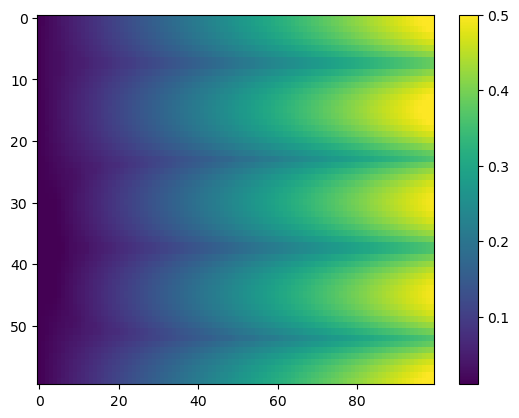

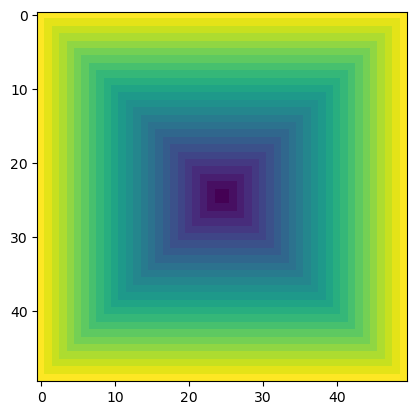

Polar Matrix Shape: (60, 100)


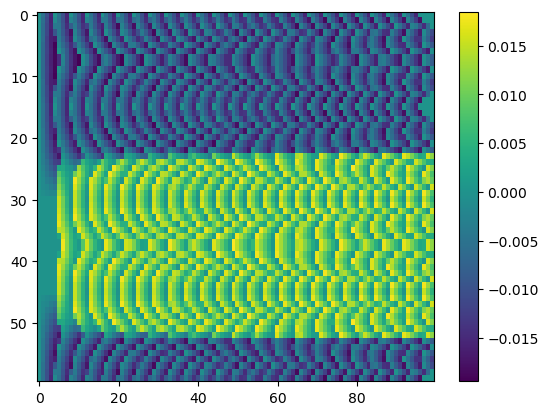

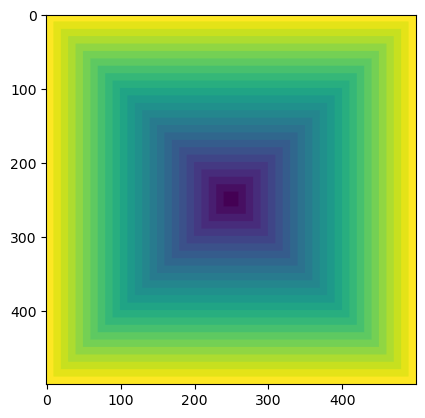

In [153]:

def cartesian_to_polar_opencv(matrix,num_phi=360,num_rad = None):
    rows, cols = matrix.shape
    center = (cols // 2, rows // 2)  # Define center as origin
    max_radius = min(cols, rows) // 2
    if num_rad is None:
        num_rad = max_radius
    # Convert Cartesian to Polar using OpenCV's warpPolar
    polar_matrix = cv2.warpPolar(
        matrix, (num_rad, num_phi), center, max_radius,
        cv2.WARP_POLAR_LINEAR + cv2.INTER_LINEAR
    )

    return polar_matrix

def upscale_matrix(matrix, scale_factor=3):
    # Upscale the matrix by replicating each pixel into a 3x3 block
    upscaled_matrix = cv2.resize(matrix, (matrix.shape[1] * scale_factor, matrix.shape[0] * scale_factor),
                                 interpolation=cv2.INTER_NEAREST)
    return upscaled_matrix

x = np.linspace(0,1,50)
XX, YY = np.meshgrid(x,x)

matrix = (np.maximum(np.abs(XX-1/2),np.abs(YY-1/2))).astype(np.float32)  #  Example 100x100 matrix
matrix2 = upscale_matrix(matrix, scale_factor=10)



polar_matrix = cartesian_to_polar_opencv(matrix,num_phi=60, num_rad=100)
polar_matrix2 = cartesian_to_polar_opencv(matrix2,num_phi=60, num_rad=100)

print("Polar Matrix Shape:", polar_matrix.shape)
plt.imshow(polar_matrix, aspect='auto')
plt.colorbar()
plt.show()
plt.imshow(matrix)
plt.show()


print("Polar Matrix Shape:", polar_matrix2.shape)
plt.imshow(polar_matrix2-polar_matrix, aspect='auto')
plt.colorbar()
plt.show()
plt.imshow(matrix2)
plt.show()